# Task 5: Bias analysis for domestic vs. international searches

This notebook investigates whether the LightGBM ranking model provides different ranking quality for **domestic searches** and **international / non-domestic searches**.

A domestic search is defined as a search where the visitor country and hotel country are the same:

```python
domestic_search = visitor_location_country_id == prop_country_id
```

The potential bias is a **quality-of-service bias**: if the model ranks relevant hotels less accurately for international travellers, those users receive lower-quality recommendations.

The mitigation tested here is **pre-processing re-weighting**: relevant examples from international searches receive higher training weights before retraining the LightGBM Ranker.

In [1]:
# ---------------------------------------------------
# Cell 1: Imports and settings
# ---------------------------------------------------

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# ---------------------------------------------------
# Cell 2: Load prepared feature files from Task 3
# ---------------------------------------------------

train_feat = pd.read_parquet("data/train_features.parquet")
val_feat = pd.read_parquet("data/val_features.parquet")

print("Train features:", train_feat.shape)
print("Validation features:", val_feat.shape)

display(train_feat.head())

Train features: (3980039, 177)
Validation features: (978308, 177)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,relevance,visitor_hist_starrating_missing,visitor_hist_adr_usd_missing,srch_query_affinity_score_missing,orig_destination_distance_missing,prop_location_score2_missing,prop_review_score_missing,prop_review_score_is_zero,prop_starrating_is_zero,price_is_zero,price_below_1,price_below_10,price_usd_capped,price_usd_clipped,log_price_usd,log_price_usd_capped,log_price_usd_clipped,log_orig_destination_distance,total_guests,children_present,multi_room,domestic_search,log_booking_window,log_length_of_stay,last_minute_booking,long_booking_window,long_stay,is_4_star,is_5_star,high_review_score,search_month,search_quarter,search_dayofweek,search_hour,search_is_weekend,comp_rate_missing_count,comp_inv_missing_count,comp_pct_missing_count,comp_has_any_rate_data,comp_has_any_inv_data,comp_has_any_pct_data,comp_expedia_cheaper_count,comp_expedia_more_expensive_count,comp_same_price_count,comp_unavailable_count,comp_available_count,comp1_rate_missing,comp1_inv_missing,comp1_rate_percent_diff_missing,comp2_rate_missing,comp2_inv_missing,comp2_rate_percent_diff_missing,comp3_rate_missing,comp3_inv_missing,comp3_rate_percent_diff_missing,comp4_rate_missing,comp4_inv_missing,comp4_rate_percent_diff_missing,comp5_rate_missing,comp5_inv_missing,comp5_rate_percent_diff_missing,comp6_rate_missing,comp6_inv_missing,comp6_rate_percent_diff_missing,comp7_rate_missing,comp7_inv_missing,comp7_rate_percent_diff_missing,comp8_rate_missing,comp8_inv_missing,comp8_rate_percent_diff_missing,comp_no_rate_data_count,comp_no_inv_data_count,hotels_in_search,search_price_mean,search_price_median,search_price_min,search_price_max,price_diff_from_search_mean,price_diff_from_search_median,price_diff_from_search_min,price_ratio_to_search_mean,price_ratio_to_search_median,price_rank_in_search,price_pct_rank_in_search,search_log_price_mean,log_price_diff_from_search_mean,search_star_mean,search_star_max,star_diff_from_search_mean,star_diff_from_search_max,star_rank_in_search,star_pct_rank_in_search,search_review_mean,search_review_max,review_diff_from_search_mean,review_diff_from_search_max,review_rank_in_search,review_pct_rank_in_search,search_location1_mean,search_location2_mean,location1_diff_from_search_mean,location2_diff_from_search_mean,location2_rank_in_search,location2_pct_rank_in_search,search_promotion_rate,promotion_above_search_avg,prop_id_count,prop_id_mean_price,prop_id_median_price,prop_id_std_price,prop_id_mean_log_price,prop_id_mean_starrating,prop_id_mean_review_score,prop_id_mean_location_score1,prop_id_mean_location_score2,prop_id_mean_promotion_flag,dest_id_count,dest_id_mean_price,dest_id_median_price,dest_id_mean_starrating,dest_id_mean_review_score,dest_id_mean_location_score2,prop_dest_count
0,1,2013-04-04 08:32:15,12,187,-1.0,-1.0,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,-327.567505,392.559998,1,-2.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,0,NaN,0,0,1,1,1,1,0,0,0,0,0,0,0,104.769997,104.769997,4.661267,4.661267,4.661267,5.975234,4,0,0,0,0.0,0.693147,1,0,0,0,0,0,4,2,3,8,0,4,4,8,1,1,0,0,0,4,0,4,1,1,1,0

In [3]:
# ---------------------------------------------------
# Cell 3: Define domestic vs. international search group
# ---------------------------------------------------
# domestic_search = 1 means the visitor country and hotel country are the same.
# domestic_search = 0 means international/non-domestic/unknown-context search.

for df in [train_feat, val_feat]:
    df["domestic_search"] = (
        df["visitor_location_country_id"] == df["prop_country_id"]
    ).astype(np.int8)

# Human-readable group labels for validation analysis.
val_feat["domestic_group"] = np.where(
    val_feat["domestic_search"] == 1,
    "Domestic searches",
    "International searches"
)

train_feat["domestic_group"] = np.where(
    train_feat["domestic_search"] == 1,
    "Domestic searches",
    "International searches"
)

# Search-level group table.
# A search should normally have one visitor country, but can contain hotels from different countries.
# We classify a search as domestic if at least one shown property is in the visitor's country.
search_group_summary = val_feat.groupby("domestic_group").agg(
    rows=("srch_id", "size"),
    searches=("srch_id", "nunique"),
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    mean_relevance=("relevance", "mean"),
    mean_price=("price_usd", "mean"),
    mean_distance=("orig_destination_distance", "mean")
).reset_index()

display(search_group_summary)

,domestic_group,rows,searches,click_rate,booking_rate,mean_relevance,mean_price,mean_distance
0,Domestic searches,632156,25781,0.044557,0.029085,0.160895,252.778940,504.181030
1,International searches,346152,14284,0.046251,0.027693,0.157024,540.085716,1853.067993


In [4]:
# ---------------------------------------------------
# Cell 4: Build feature columns
# ---------------------------------------------------
# We keep the same logic as Task 4: remove identifiers, target-related variables,
# and non-numeric columns. The domestic_search feature itself is allowed here.

NON_FEATURE_COLS = [
    "srch_id",
    "prop_id",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
    "relevance",
    "domestic_group"
]

feature_cols = [
    col for col in train_feat.columns
    if col not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(train_feat[col])
]

missing_in_val = set(feature_cols) - set(val_feat.columns)
extra_in_val = set(val_feat.columns) - set(train_feat.columns)

print("Number of model features:", len(feature_cols))
print("Missing in validation:", missing_in_val)
print("Extra columns in validation compared with train:", len(extra_in_val))
print("First 40 features:")
print(feature_cols[:40])

Number of model features: 169
Missing in validation: set()
Extra columns in validation compared with train: 0
First 40 features:
['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv']


In [5]:
# ---------------------------------------------------
# Cell 5: Sort by search ID and create LightGBM matrices
# ---------------------------------------------------
# LightGBM Ranker needs rows sorted by group, and group sizes must match row order.

train_feat = train_feat.sort_values("srch_id").reset_index(drop=True)
val_feat = val_feat.sort_values("srch_id").reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["relevance"].astype(int)

y_val = val_feat["relevance"].astype(int)
X_val = val_feat[feature_cols]

group_train = train_feat.groupby("srch_id").size().to_numpy()
group_val = val_feat.groupby("srch_id").size().to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of train search groups:", len(group_train))
print("Number of validation search groups:", len(group_val))

X_train: (3980039, 169)
X_val: (978308, 169)
Number of train search groups: 159836
Number of validation search groups: 39959


In [6]:
# ---------------------------------------------------
# Cell 6: NDCG and group evaluation helper functions
# ---------------------------------------------------

def dcg_at_k(relevances, k=5):
    """Compute DCG@k for one ranked list."""
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    gains = (2 ** relevances - 1)
    return np.sum(gains / discounts)


def ndcg_at_k_for_group(y_true, y_score, k=5):
    """Compute NDCG@k for one search group."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)
    ranked_relevance = y_true[order]

    ideal_order = np.argsort(-y_true)
    ideal_relevance = y_true[ideal_order]

    dcg = dcg_at_k(ranked_relevance, k=k)
    idcg = dcg_at_k(ideal_relevance, k=k)

    if idcg == 0:
        return 0.0
    return dcg / idcg


def mean_ndcg_at_k(df, y_true_col="relevance", y_score_col="score", group_col="srch_id", k=5):
    """Compute mean NDCG@k over all searches."""
    scores = []
    for _, group in df.groupby(group_col):
        scores.append(
            ndcg_at_k_for_group(
                group[y_true_col].to_numpy(),
                group[y_score_col].to_numpy(),
                k=k
            )
        )
    return float(np.mean(scores))


def evaluate_domestic_bias(val_df, scores, model_name, k=5):
    """
    Evaluate ranking quality separately for domestic and international searches.

    Metrics:
    - overall NDCG@5
    - NDCG@5 by group
    - booked-hotel Recall@5 by group
    - booked top-1 hit rate by group
    - mean rank of booked hotel by group
    """
    eval_df = val_df[[
        "srch_id",
        "prop_id",
        "relevance",
        "booking_bool",
        "domestic_search",
        "domestic_group"
    ]].copy()

    eval_df["score"] = scores

    overall_ndcg = mean_ndcg_at_k(eval_df, k=k)

    group_results = []

    for group_label, group_rows in eval_df.groupby("domestic_group"):
        group_srch_ids = group_rows["srch_id"].unique()
        group_eval = eval_df[eval_df["srch_id"].isin(group_srch_ids)].copy()

        group_ndcg = mean_ndcg_at_k(group_eval, k=k)

        booked_searches = 0
        booked_in_topk = 0
        booked_top1 = 0
        booked_ranks = []

        for _, search_df in group_eval.groupby("srch_id"):
            sorted_search = search_df.sort_values("score", ascending=False).reset_index(drop=True)
            booked_positions = sorted_search.index[sorted_search["booking_bool"].to_numpy() == 1].to_numpy()

            if len(booked_positions) > 0:
                booked_searches += 1
                best_booked_rank = int(booked_positions[0]) + 1
                booked_ranks.append(best_booked_rank)

                if best_booked_rank <= k:
                    booked_in_topk += 1
                if best_booked_rank == 1:
                    booked_top1 += 1

        booked_recall_at_k = booked_in_topk / booked_searches if booked_searches > 0 else np.nan
        booked_top1_hit_rate = booked_top1 / booked_searches if booked_searches > 0 else np.nan
        mean_booked_rank = float(np.mean(booked_ranks)) if len(booked_ranks) > 0 else np.nan

        group_results.append({
            "group": group_label,
            "num_searches": len(group_srch_ids),
            "num_booked_searches": booked_searches,
            "mean_ndcg_at_5": group_ndcg,
            "booked_recall_at_5": booked_recall_at_k,
            "booked_top1_hit_rate": booked_top1_hit_rate,
            "mean_booked_rank": mean_booked_rank
        })

    group_results = pd.DataFrame(group_results)

    domestic_row = group_results[group_results["group"] == "Domestic searches"].iloc[0]
    international_row = group_results[group_results["group"] == "International searches"].iloc[0]

    metrics = {
        "model": model_name,
        "overall_ndcg@5": overall_ndcg,
        "domestic_ndcg@5": domestic_row["mean_ndcg_at_5"],
        "international_ndcg@5": international_row["mean_ndcg_at_5"],
        "international_minus_domestic_ndcg@5": international_row["mean_ndcg_at_5"] - domestic_row["mean_ndcg_at_5"],
        "domestic_booked_recall@5": domestic_row["booked_recall_at_5"],
        "international_booked_recall@5": international_row["booked_recall_at_5"],
        "international_minus_domestic_recall@5": international_row["booked_recall_at_5"] - domestic_row["booked_recall_at_5"],
        "domestic_top1_hit_rate": domestic_row["booked_top1_hit_rate"],
        "international_top1_hit_rate": international_row["booked_top1_hit_rate"],
        "domestic_mean_booked_rank": domestic_row["mean_booked_rank"],
        "international_mean_booked_rank": international_row["mean_booked_rank"],
        "num_domestic_searches": int(domestic_row["num_searches"]),
        "num_international_searches": int(international_row["num_searches"]),
        "num_domestic_booked_searches": int(domestic_row["num_booked_searches"]),
        "num_international_booked_searches": int(international_row["num_booked_searches"])
    }

    return metrics, group_results, eval_df

In [7]:
# ---------------------------------------------------
# Cell 7: Train original LightGBM Ranker
# ---------------------------------------------------
# These are the best parameters from Task 4.

best_parameters = {
    "num_leaves": 383,
    "learning_rate": 0.02,
    "min_child_samples": 900,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 286
}

original_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],

    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

original_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("Original model trained.")

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.497638 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.383334
[200]	valid_0's ndcg@5: 0.385888
Original model trained.


In [8]:
# ---------------------------------------------------
# Cell 8: Evaluate original model for domestic/international bias
# ---------------------------------------------------

original_scores = original_ranker.predict(X_val)

original_metrics, original_group_results, original_eval_df = evaluate_domestic_bias(
    val_df=val_feat,
    scores=original_scores,
    model_name="Original LightGBM Ranker",
    k=K
)

display(original_group_results)
display(pd.DataFrame([original_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18420,0.396667,0.605863,0.226873,6.465852
1,International searches,14284,9621,0.370143,0.572394,0.207879,6.993764


,value
model,Original LightGBM Ranker
overall_ndcg@5,0.387156
domestic_ndcg@5,0.396667
international_ndcg@5,0.370143
international_minus_domestic_ndcg@5,-0.026524
domestic_booked_recall@5,0.605863
international_booked_recall@5,0.572394
international_minus_domestic_recall@5,-0.033469
domestic_top1_hit_rate,0.226873
international_top1_hit_rate,0.207879


In [9]:
# ---------------------------------------------------
# Cell 9: Create pre-processing re-weighting for international searches
# ---------------------------------------------------
# We only apply the mitigation if international searches are the disadvantaged group.
# The weights below make relevant examples in international searches more influential.

sample_weight_international = np.ones(len(train_feat), dtype=np.float32)

# International/non-domestic relevant hotels get a higher weight.
sample_weight_international[
    (train_feat["domestic_search"] == 0) &
    (train_feat["relevance"] > 0)
] = 1.25

# Booked hotels in international searches get the highest weight.
sample_weight_international[
    (train_feat["domestic_search"] == 0) &
    (train_feat["relevance"] == 5)
] = 1.50

weight_summary = pd.Series(sample_weight_international).value_counts().sort_index().reset_index()
weight_summary.columns = ["weight", "count"]
weight_summary["share"] = weight_summary["count"] / len(sample_weight_international)

display(weight_summary)

,weight,count,share
0,1.00,3913178,0.983201
1,1.25,28434,0.007144
2,1.50,38427,0.009655


In [10]:
# ---------------------------------------------------
# Cell 10: Train mitigated LightGBM Ranker with international-search re-weighting
# ---------------------------------------------------

international_weighted_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],

    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

international_weighted_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    sample_weight=sample_weight_international,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("International-search re-weighted model trained.")

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.513144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.38195
[200]	valid_0's ndcg@5: 0.382184
International-search re-weighted model trained.


In [11]:
# ---------------------------------------------------
# Cell 11: Evaluate mitigated model
# ---------------------------------------------------

weighted_scores = international_weighted_ranker.predict(X_val)

weighted_metrics, weighted_group_results, weighted_eval_df = evaluate_domestic_bias(
    val_df=val_feat,
    scores=weighted_scores,
    model_name="International re-weighted LightGBM Ranker",
    k=K
)

display(weighted_group_results)
display(pd.DataFrame([weighted_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18420,0.392565,0.600760,0.222258,6.538111
1,International searches,14284,9621,0.358815,0.555659,0.199460,7.181374


,value
model,International re-weighted LightGBM Ranker
overall_ndcg@5,0.380616
domestic_ndcg@5,0.392565
international_ndcg@5,0.358815
international_minus_domestic_ndcg@5,-0.03375
domestic_booked_recall@5,0.60076
international_booked_recall@5,0.555659
international_minus_domestic_recall@5,-0.045101
domestic_top1_hit_rate,0.222258
international_top1_hit_rate,0.19946


In [12]:
# ---------------------------------------------------
# Cell 12: Compare original and mitigated model
# ---------------------------------------------------

comparison_df = pd.DataFrame([original_metrics, weighted_metrics])
comparison_display = comparison_df.copy()

for col in comparison_display.columns:
    if col != "model":
        comparison_display[col] = pd.to_numeric(comparison_display[col], errors="coerce")

numeric_cols = comparison_display.select_dtypes(include=["number"]).columns
comparison_display[numeric_cols] = comparison_display[numeric_cols].round(6)

display(comparison_display)
display(comparison_display.T)

,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original LightGBM Ranker,0.387156,0.396667,0.370143,-0.026524,0.605863,0.572394,-0.033469,0.226873,0.207879,6.465852,6.993764,25781,14284,18420,9621
1,International re-weighted LightGBM Ranker,0.380616,0.392565,0.358815,-0.033750,0.600760,0.555659,-0.045101,0.222258,0.199460,6.538111,7.181374,25781,14284,18420,9621


,0,1
model,Original LightGBM Ranker,International re-weighted LightGBM Ranker
overall_ndcg@5,0.387156,0.380616
domestic_ndcg@5,0.396667,0.392565
international_ndcg@5,0.370143,0.358815
international_minus_domestic_ndcg@5,-0.026524,-0.03375
domestic_booked_recall@5,0.605863,0.60076
international_booked_recall@5,0.572394,0.555659
international_minus_domestic_recall@5,-0.033469,-0.045101
domestic_top1_hit_rate,0.226873,0.222258
international_top1_hit_rate,0.207879,0.19946


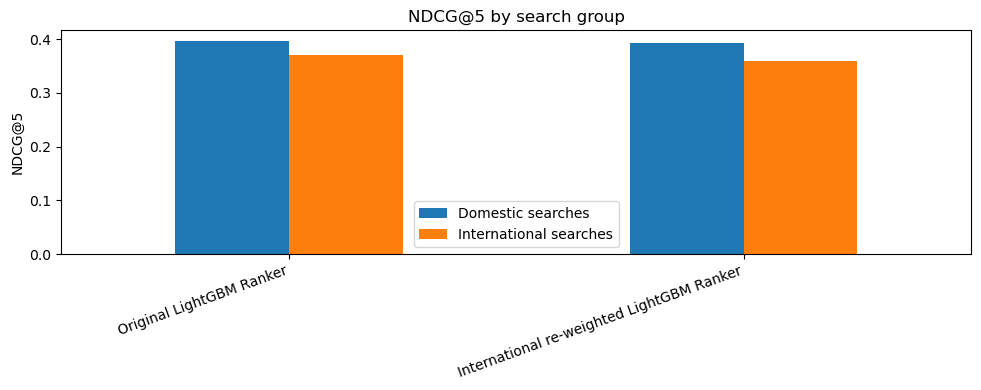

In [13]:
# ---------------------------------------------------
# Cell 13: Plot NDCG@5 by group
# ---------------------------------------------------

plot_df = comparison_display[["model", "domestic_ndcg@5", "international_ndcg@5"]].copy()
plot_df = plot_df.rename(columns={
    "domestic_ndcg@5": "Domestic searches",
    "international_ndcg@5": "International searches"
})

ax = plot_df.set_index("model")[["Domestic searches", "International searches"]].plot(kind="bar", figsize=(10, 4))
ax.set_title("NDCG@5 by search group")
ax.set_ylabel("NDCG@5")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

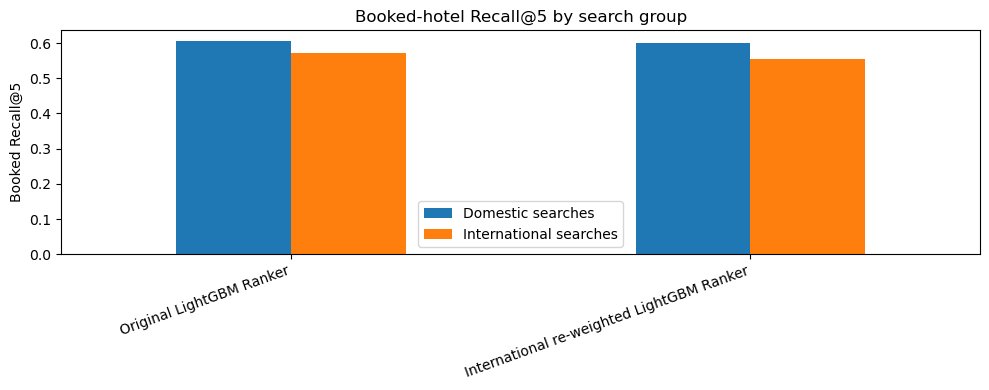

In [14]:
# ---------------------------------------------------
# Cell 14: Plot booked Recall@5 by group
# ---------------------------------------------------

plot_df = comparison_display[["model", "domestic_booked_recall@5", "international_booked_recall@5"]].copy()
plot_df = plot_df.rename(columns={
    "domestic_booked_recall@5": "Domestic searches",
    "international_booked_recall@5": "International searches"
})

ax = plot_df.set_index("model")[["Domestic searches", "International searches"]].plot(kind="bar", figsize=(10, 4))
ax.set_title("Booked-hotel Recall@5 by search group")
ax.set_ylabel("Booked Recall@5")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

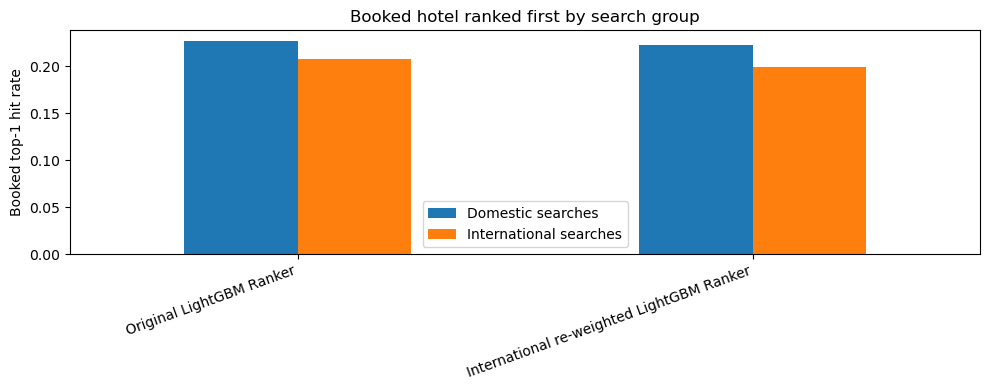

In [15]:
# ---------------------------------------------------
# Cell 15: Plot booked top-1 hit rate by group
# ---------------------------------------------------

plot_df = comparison_display[["model", "domestic_top1_hit_rate", "international_top1_hit_rate"]].copy()
plot_df = plot_df.rename(columns={
    "domestic_top1_hit_rate": "Domestic searches",
    "international_top1_hit_rate": "International searches"
})

ax = plot_df.set_index("model")[["Domestic searches", "International searches"]].plot(kind="bar", figsize=(10, 4))
ax.set_title("Booked hotel ranked first by search group")
ax.set_ylabel("Booked top-1 hit rate")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------
# Cell 16: Create a compact report table
# ---------------------------------------------------

report_cols = [
    "model",
    "overall_ndcg@5",
    "domestic_ndcg@5",
    "international_ndcg@5",
    "international_minus_domestic_ndcg@5",
    "domestic_booked_recall@5",
    "international_booked_recall@5",
    "international_minus_domestic_recall@5",
    "domestic_top1_hit_rate",
    "international_top1_hit_rate",
    "domestic_mean_booked_rank",
    "international_mean_booked_rank"
]

report_table = comparison_display[report_cols].copy()
display(report_table)

,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank
0,Original LightGBM Ranker,0.387156,0.396667,0.370143,-0.026524,0.605863,0.572394,-0.033469,0.226873,0.207879,6.465852,6.993764
1,International re-weighted LightGBM Ranker,0.380616,0.392565,0.358815,-0.033750,0.600760,0.555659,-0.045101,0.222258,0.199460,6.538111,7.181374


In [17]:
# ---------------------------------------------------
# Cell 17: Save Task 5 domestic/international results
# ---------------------------------------------------

comparison_display.to_csv("task5_domestic_international_bias_results.csv", index=False)
original_group_results.to_csv("task5_domestic_international_original_group_results.csv", index=False)
weighted_group_results.to_csv("task5_domestic_international_weighted_group_results.csv", index=False)
report_table.to_csv("task5_domestic_international_report_table.csv", index=False)

print("Saved:")
print("- task5_domestic_international_bias_results.csv")
print("- task5_domestic_international_original_group_results.csv")
print("- task5_domestic_international_weighted_group_results.csv")
print("- task5_domestic_international_report_table.csv")

Saved:
- task5_domestic_international_bias_results.csv
- task5_domestic_international_original_group_results.csv
- task5_domestic_international_weighted_group_results.csv
- task5_domestic_international_report_table.csv


## How to interpret the result

Use the original model results first to decide whether a bias is present.

- If `international_ndcg@5` and `international_booked_recall@5` are clearly lower than the domestic metrics, this suggests lower quality of service for international searches.
- If the re-weighted model improves international-search metrics while only slightly reducing overall NDCG@5, then the mitigation is useful.
- If the re-weighted model lowers overall NDCG@5 strongly or only makes the metrics more equal by hurting domestic searches, then the mitigation is not beneficial for deployment.

For the report, be honest: a mitigation can be tested and rejected if the evaluation shows that it harms performance or overcorrects.